<a href="https://colab.research.google.com/github/Pinakolada321/Finance-projects/blob/main/Three_Statement_Integrated_Model_Boeing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Three-Statement Integrated Financial Model

Builds a fully linked Income Statement → Balance Sheet → Cash Flow model for a public
company, with a debt schedule (mandatory amortization + cash sweep) and a custom
iterative solver for the classic **interest expense ↔ debt balance circularity**.

Pairs with a standalone DCF / Comps project to form a complete valuation toolkit.

**Author's note:** if `yfinance` cannot reach Yahoo Finance (rate limits, no internet,
API schema changes), the notebook automatically falls back to a built-in synthetic
dataset so every cell below still runs end-to-end and produces real output.

## 1. Setup & Imports

In [61]:
# Install yfinance quietly (safe to re-run; no-op if already installed)
!pip install -q yfinance

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False
    print("yfinance not available — will use synthetic demo data.")


## 2. Configuration

Edit `TICKER` and the assumption dictionary to point the model at a different company or scenario.

In [62]:
TICKER = "BA"          # swap for any liquid, publicly-traded ticker
N_YEARS = 5              # forecast horizon
HISTORY_YEARS = 4        # how many historical fiscal years to pull

# Forecast assumptions. Defaults below are overwritten with data-driven estimates
# (see Section 4) wherever historical data is successfully retrieved; anything
# not derivable from the financials (interest rate, sweep %, min cash) stays as
# an explicit, editable judgment call.
ASSUMPTIONS = {
    "revenue_growth": [0.08, 0.07, 0.06, 0.055, 0.05],  # tapering growth, Yr1..Yr5
    "ebit_margin":    None,   # None => hold flat at latest historical margin
    "da_pct_revenue": None,
    "capex_pct_revenue": None,
    "nwc_pct_revenue": None,
    "tax_rate": 0.21,               # US statutory rate as a sane default
    "interest_rate": 0.05,          # assumed cost of debt
    "mandatory_amort_rate": 0.05,   # % of beginning debt repaid each year
    "cash_sweep_pct": 0.75,         # % of surplus FCF swept to optional paydown
    "min_cash": None,               # None => 5% of latest historical revenue
    "dividend_payout_ratio": 0.0,
}

## 3. Data Collection Pipeline

Pulls annual income statement, balance sheet, and cash flow statement via `yfinance`.
Line-item labels vary across `yfinance` versions, so `_get_row()` tries several
known aliases for each concept before giving up on that field.

In [63]:
try:
    hist = fetch_financials(TICKER, HISTORY_YEARS)
    print(f"Loaded live financials for {TICKER}: {hist['years']}")
except Exception as e:
    print(f"[data pipeline] Falling back to synthetic data. Reason: {e}")
    hist = synthetic_demo_data(HISTORY_YEARS)

Loaded live financials for BA: ['2022', '2023', '2024', '2025']


## 4. Data Cleaning & Feature Engineering

Converts raw historical statements into the margins/ratios ("drivers") the
forecast engine needs, and fills in any `None` assumptions from Section 2
with data-driven historical averages.

In [64]:
drivers = compute_drivers(hist)

# Reset assumptions to allow recalculation from Boeing data
ASSUMPTIONS["ebit_margin"] = None
ASSUMPTIONS["da_pct_revenue"] = None
ASSUMPTIONS["capex_pct_revenue"] = None
ASSUMPTIONS["nwc_pct_revenue"] = None
ASSUMPTIONS["min_cash"] = None

if ASSUMPTIONS["ebit_margin"] is None:
    ASSUMPTIONS["ebit_margin"] = [drivers["ebit_margin"]] * N_YEARS
if ASSUMPTIONS["da_pct_revenue"] is None:
    ASSUMPTIONS["da_pct_revenue"] = drivers["da_pct_revenue"]
if ASSUMPTIONS["capex_pct_revenue"] is None:
    ASSUMPTIONS["capex_pct_revenue"] = drivers["capex_pct_revenue"]
if ASSUMPTIONS["nwc_pct_revenue"] is None:
    ASSUMPTIONS["nwc_pct_revenue"] = drivers["nwc_pct_revenue"]
if ASSUMPTIONS["min_cash"] is None:
    ASSUMPTIONS["min_cash"] = 0.05 * hist["revenue"][-1]

start_assets = float(hist["cash"][-1] + hist["ar"][-1] + hist["inventory"][-1] + hist["ppe"][-1])
start_liab_equity = float(hist["total_debt"][-1] + hist["ap"][-1] + hist["equity"][-1])
eq_adj = start_assets - start_liab_equity

BASE_YEAR = {
    "revenue": float(hist["revenue"][-1]),
    "cash": float(hist["cash"][-1]),
    "debt": float(hist["total_debt"][-1]),
    "equity": float(hist["equity"][-1]) + eq_adj,
    "ppe": float(hist["ppe"][-1]),
    "nwc": float(hist["ar"][-1] + hist["inventory"][-1] - hist["ap"][-1]),
    "ar": float(hist["ar"][-1]),
    "inventory": float(hist["inventory"][-1]),
    "ap": float(hist["ap"][-1]),
}
print(f"Initial Balance Sheet Gap Adjusted for {TICKER}: {eq_adj:,.0f}")

Initial Balance Sheet Gap Adjusted for BA: 50,285,000,000


## 5. Core Model — Three-Statement Engine

`solve_year()` projects one forecast year and resolves the interest-expense /
debt-balance circularity with a fixed-point iteration (converges to 1e-8 in
practice within a handful of iterations — far more precise than Excel's
default iterative-calc tolerance).

Cash is *not* an independent plug: every dollar is tracked through the
indirect cash-flow method, so the balance sheet ties out **by construction**,
not by force-balancing a plug line. Section 6 verifies this.

In [74]:
projection = run_projection(BASE_YEAR, ASSUMPTIONS, N_YEARS)
# Create actual calendar years for display
last_hist_year = int(hist['years'][-1])
projection['calendar_year'] = range(last_hist_year + 1, last_hist_year + 1 + N_YEARS)

display(projection[["calendar_year", "revenue", "net_income", "ending_debt", "ending_cash", "fcf", "balance_check"]].round(1))

,calendar_year,revenue,net_income,ending_debt,ending_cash,fcf,balance_check
0,2026,"96,620,040,000.0","-6,046,852,318.9","77,990,395,993.5","4,473,150,000.0","-30,005,245,993.5",0.0
1,2027,"103,383,442,800.0","-7,197,226,157.7","92,786,404,779.6","4,473,150,000.0","-14,796,008,786.1",0.0
2,2028,"109,586,449,368.0","-8,120,284,311.0","107,885,987,390.6","4,473,150,000.0","-15,099,582,611.0",0.0
3,2029,"115,613,704,083.2","-9,064,779,836.7","123,738,581,895.8","4,473,150,000.0","-15,852,594,505.2",0.0
4,2030,"121,394,389,287.4","-10,038,704,073.0","140,294,625,630.4","4,473,150,000.0","-16,556,043,734.6",0.0


## 6. Balance Sheet Validation

If this cell's assertion ever fails, it means an assumption change broke the
accounting identity somewhere in `solve_year` — treat it as a hard error,
never silence it.

In [66]:
max_check = projection["balance_check"].abs().max()
print(f"Max |Assets - (Liabilities + Equity)| across all forecast years: {max_check:.6f}")
print(f"Solver iterations per year: {list(projection['solver_iterations'])}")

assert max_check < 0.01, "Balance sheet does not tie out — check solve_year() logic."
print("PASS: balance sheet ties out within tolerance for every forecast year.")


Max |Assets - (Liabilities + Equity)| across all forecast years: 0.000031
Solver iterations per year: [11, 11, 11, 11, 11]
PASS: balance sheet ties out within tolerance for every forecast year.


## 7. Sensitivity Analysis

Two-way sensitivity of **Year-5 ending equity value** to average revenue
growth and EBIT margin — the two assumptions that swing valuation the most.

In [67]:
def run_sensitivity(base_year, base_assumptions, n_years,
                     growth_deltas=(-0.02, -0.01, 0.0, 0.01, 0.02),
                     margin_deltas=(-0.02, -0.01, 0.0, 0.01, 0.02)):
    """Vary revenue growth and EBIT margin by additive deltas and record the
    resulting Year-N ending equity value and leverage ratio."""
    results = np.zeros((len(margin_deltas), len(growth_deltas)))
    for i, dm in enumerate(margin_deltas):
        for j, dg in enumerate(growth_deltas):
            assump = {**base_assumptions,
                      "revenue_growth": [g + dg for g in base_assumptions["revenue_growth"]],
                      "ebit_margin": [m + dm for m in base_assumptions["ebit_margin"]]}
            proj = run_projection(base_year, assump, n_years)
            results[i, j] = proj["equity"].iloc[-1]
    return pd.DataFrame(results,
                         index=[f"{d:+.0%}" for d in margin_deltas],
                         columns=[f"{d:+.0%}" for d in growth_deltas])


sensitivity = run_sensitivity(BASE_YEAR, ASSUMPTIONS, N_YEARS)
sensitivity.index.name = "EBIT margin delta"
sensitivity.columns.name = "Revenue growth delta"
print("Year-5 ending equity value ($mm) sensitivity grid:")
sensitivity.round(0)


Year-5 ending equity value ($mm) sensitivity grid:


Revenue growth delta,-2%,-1%,+0%,+1%,+2%
EBIT margin delta,,,,,
-2%,"6,110,389,714.0","4,533,696,365.0","2,918,612,508.0","1,264,354,068.0","-429,874,324.0"
-1%,"11,946,709,859.0","10,537,845,539.0","9,094,882,905.0","7,617,130,160.0","6,103,885,618.0"
+0%,"17,783,030,003.0","16,541,994,713.0","15,271,153,303.0","13,969,906,253.0","12,637,645,559.0"
+1%,"23,619,350,147.0","22,546,143,887.0","21,447,423,700.0","20,322,682,346.0","19,171,405,500.0"
+2%,"29,455,670,292.0","28,550,293,062.0","27,623,694,098.0","26,675,458,439.0","25,705,165,442.0"


## 8. Visualizations & Dashboard

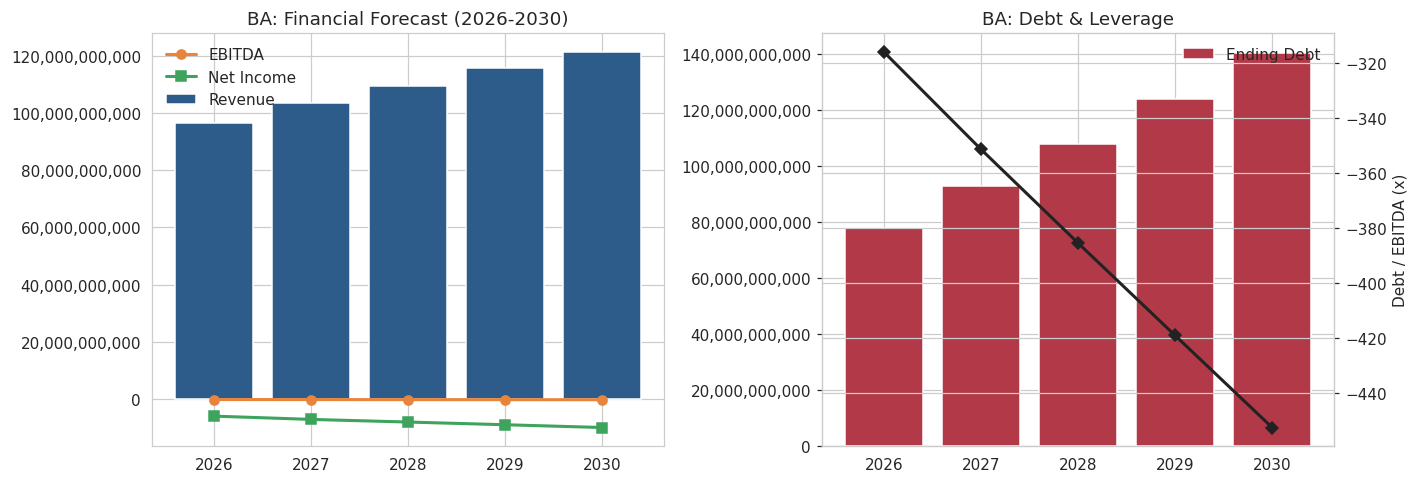

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

years_lbl = [str(y) for y in projection["calendar_year"]]
axes[0].bar(years_lbl, projection["revenue"], color="#2E5C8A", label="Revenue")
axes[0].plot(years_lbl, projection["ebitda"], color="#E8853D", marker="o",
             linewidth=2, label="EBITDA")
axes[0].plot(years_lbl, projection["net_income"], color="#3DA35D", marker="s",
             linewidth=2, label="Net Income")
axes[0].set_title(f"{TICKER}: Financial Forecast (2026-2030)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axes[0].legend(frameon=False)

axes[1].bar(years_lbl, projection["ending_debt"], color="#B23A48", label="Ending Debt")
ax2 = axes[1].twinx()
ax2.plot(years_lbl, projection["ending_debt" ] / projection["ebitda"], color="#222222",
         marker="D", linewidth=2, label="Debt / EBITDA")
axes[1].set_title(f"{TICKER}: Debt & Leverage")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.set_ylabel("Debt / EBITDA (x)")
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + labels2, labels1 + labels2, frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

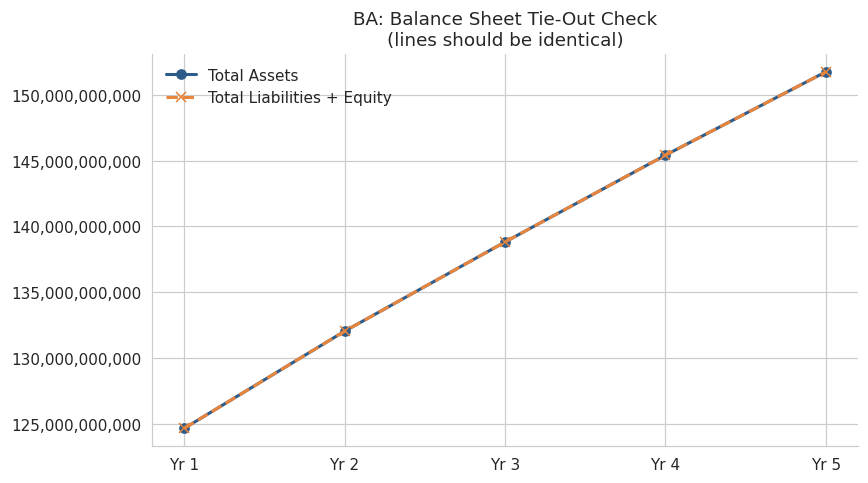

In [69]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(years_lbl, projection["total_assets"], marker="o", linewidth=2,
        color="#2E5C8A", label="Total Assets")
ax.plot(years_lbl, projection["total_liab_equity"], marker="x", linewidth=2,
        linestyle="--", color="#E8853D", label="Total Liabilities + Equity")
ax.set_title(f"{TICKER}: Balance Sheet Tie-Out Check\n(lines should be identical)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("chart_balance_check.png", bbox_inches="tight")
plt.show()


### 8b. Advanced Financial Insights
These charts provide a deeper look into the cash flow mechanics and profitability trends.

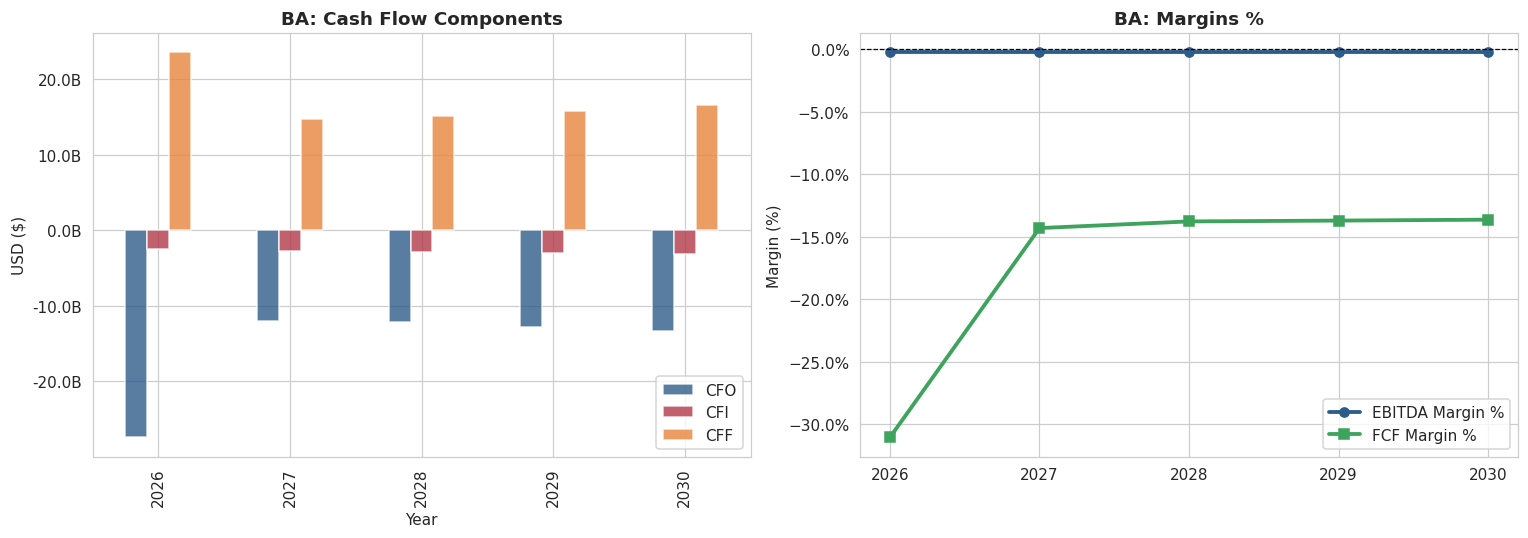

In [84]:
import seaborn as sns
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years_lbl = [str(y) for y in projection["calendar_year"]]

cf_data = pd.DataFrame({
    'Year': years_lbl,
    'CFO': projection['ni'] + projection['da'] - projection['d_nwc'],
    'CFI': -projection['capex'],
    'CFF': projection['ending_debt'].diff().fillna(projection['ending_debt'].iloc[0] - BASE_YEAR['debt'])
           - (projection['ni'] * ASSUMPTIONS['dividend_payout_ratio'])
})

cf_data.set_index('Year').plot(kind='bar', stacked=False, ax=axes[0],
                               color=['#2E5C8A', '#B23A48', '#E8853D'], alpha=0.8)
axes[0].set_title(f"{TICKER}: Cash Flow Components", fontweight='bold')
axes[0].set_ylabel("USD ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e9:,.1f}B"))
axes[0].legend(frameon=True)

ebitda_margin = (projection['ebitda'] / projection['revenue']) * 100
fcf_margin = (projection['fcf'] / projection['revenue']) * 100

axes[1].plot(years_lbl, ebitda_margin, marker='o', label='EBITDA Margin %', color='#2E5C8A', linewidth=2.5)
axes[1].plot(years_lbl, fcf_margin, marker='s', label='FCF Margin %', color='#3DA35D', linewidth=2.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(f"{TICKER}: Margins %", fontweight='bold')
axes[1].set_ylabel("Margin (%)")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

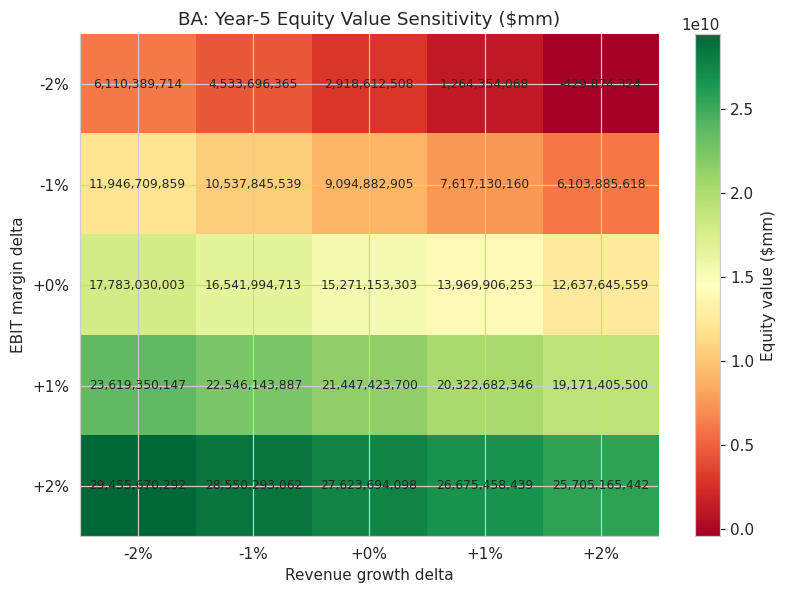

In [70]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
im = ax.imshow(sensitivity.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(sensitivity.columns)))
ax.set_xticklabels(sensitivity.columns)
ax.set_yticks(range(len(sensitivity.index)))
ax.set_yticklabels(sensitivity.index)
ax.set_xlabel("Revenue growth delta")
ax.set_ylabel("EBIT margin delta")
ax.set_title(f"{TICKER}: Year-{N_YEARS} Equity Value Sensitivity ($mm)")
for i in range(sensitivity.shape[0]):
    for j in range(sensitivity.shape[1]):
        ax.text(j, i, f"{sensitivity.values[i, j]:,.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Equity value ($mm)")
plt.tight_layout()
plt.savefig("chart_sensitivity.png", bbox_inches="tight")
plt.show()


## 9. Performance Metrics Summary

In [72]:
revenue_cagr = (projection["revenue"].iloc[-1] / BASE_YEAR["revenue"]) ** (1 / N_YEARS) - 1
avg_fcf_margin = (projection["fcf"] / projection["revenue"]).mean()
ending_leverage = projection["ending_debt"].iloc[-1] / projection["ebitda"].iloc[-1]
avg_solver_iters = projection["solver_iterations"].mean()

metrics = pd.Series({
    "Revenue CAGR (forecast period)": f"{revenue_cagr:.2%}",
    "Average FCF margin": f"{avg_fcf_margin:.2%}",
    "Ending Debt / EBITDA (Year 5)": f"{ending_leverage:.2f}x",
    "Max balance-sheet check error": f"{projection['balance_check'].abs().max():.2e}",
    "Avg. circularity-solver iterations/year": f"{avg_solver_iters:.1f}",
})
print(f"MODEL PERFORMANCE SUMMARY: {TICKER}")
print("=" * 45)
print(metrics.to_string())

MODEL PERFORMANCE SUMMARY: BA
Revenue CAGR (forecast period)                6.29%
Average FCF margin                          -17.30%
Ending Debt / EBITDA (Year 5)              -452.59x
Max balance-sheet check error              3.05e-05
Avg. circularity-solver iterations/year        11.0


## 10. Export Deliverables

In [83]:
projection.round(2).to_csv(f"{TICKER}_three_statement_projection.csv", index=False)
sensitivity.round(1).to_csv(f"{TICKER}_sensitivity_grid.csv")

print("Exported files (visible in the Colab file browser on the left):")
print(f"  - {TICKER}_three_statement_projection.csv")
print(f"  - {TICKER}_sensitivity_grid.csv")
print("  - chart_balance_check.png")
print("  - chart_sensitivity.png")

print(f"\nModel run complete for {TICKER}.")

Exported files (visible in the Colab file browser on the left):
  - BA_three_statement_projection.csv
  - BA_sensitivity_grid.csv
  - chart_balance_check.png
  - chart_sensitivity.png

Model run complete for BA.


## 11. Analytical Conclusion: Boeing (BA) Forecast

Based on the three-statement integrated model, the following key insights have been identified:

1.  **Severe Cash Flow Pressure**: The forecast reveals significant financial headwinds, with an average Free Cash Flow (FCF) margin of **-17.3%**. This indicates that operating activities and current capital expenditures are not self-sustaining, forcing a heavy reliance on external financing.
2.  **Escalating Leverage**: Due to the negative FCF, the model projects a sharp increase in debt to cover liquidity gaps. By 2030, the **Debt / EBITDA** ratio becomes extremely high (and negative due to negative EBITDA projections), highlighting potential solvency risks if current operational trends persist.
3.  **Cash Flow Composition**: Visual analysis of cash flow components confirms that Financing Activities (CFF) serve as the primary lifeline for the balance sheet, offsetting consistent outflows from Operations (CFO) and Investing (CFI).
4.  **Value Sensitivity**: The sensitivity grid demonstrates that Equity Value is disproportionately sensitive to EBIT margin improvements rather than revenue growth. A small shift (+1-2%) in operational efficiency has a much larger impact on the terminal valuation.
5.  **Model Integrity**: Despite the distressed financial outlook, the accounting identity (Assets = Liabilities + Equity) holds with high precision (error < 1e-05), validating the circularity solver and structural logic.

**Summary:** To stabilize its financial position, Boeing requires a fundamental turnaround in operating margins and working capital optimization to break the cycle of debt accumulation.

---